# Стохастический градиентный и координатный спуски

## Загрузка и подготовка данных (1 балл)

**Загрузите уже знакомый вам файл *Advertising.csv* как объект DataFrame.** 

In [1]:
#ваш код 
import pandas as pd
import numpy as np

df = pd.read_csv('C:\IDE\data\Block_5\Advertising.csv')
df

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


**Проверьте, есть ли в данных пропуски и, если они есть - удалите их**

In [2]:
#ваш код 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [88]:
#ваш код 

**Преобразуйте ваши признаки в массивы NumPy и разделите их на переменные X (предикторы) и y(целевая переменная)** 

In [3]:
#ваш код 
X = np.array(df.drop(['sales','Unnamed: 0'],axis=1))
y = np.array(df['sales'])

## Координатный спуск (2 балла)

**Добавим единичный столбец для того, чтобы у нас был свободный коэффициент в уравнении регрессии:**

In [4]:
import numpy as np

X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])
y = y.reshape(-1, 1)
print(X.shape, y.shape)

(200, 4) (200, 1)


**Нормализуем данные: обычно это необходимо для корректной работы алгоритма**

In [5]:
X = X / np.sqrt(np.sum(np.square(X), axis=0))

**Реализуйте алгоритм координатного спуска:**

Ниже приведен алгоритм координатного спуска для случая нормализованных данных:

**Задано:**

* $X=(x_{ij})$ - матрица наблюдений, размерностью $dim(X)=(m, n)$
* $N=1000$ - количество итераций

**Примечание:** *1000 итераций здесь указаны для этого задания, на самом деле их может быть намного больше, нет детерменированного значения.*

**Алгоритм (математическая запись):**
* Создать нулевой вектор параметров $w_0=(0, 0,..., 0)^T$
* Для всех $t=1, 2, ..., N$ итераций:
    * Для всех $k = 1, 2,..., n$:
        * Фиксируем значение всех признаков, кроме $k$-ого и вычисляем прогноз модели линейной регрессии.Для этого исключаем признак $k$-ый из данных и $w_j$ из параметров при построении прогноза.
        Математически это можно записать следующим образом:

        $$h_i = \sum_{j=1}^{k-1} x_{ij}w_{j} + \sum_{j=k+1}^{n} x_{ij}w_j $$

        **Примечание:**
        
        *Обратите, что в данной записи текущий признак под номером $k$ не участвует в сумме.Сравните эту запись с классической записью прогноза линейной регрессии в случае нормированных данных (когда участвуют все признаки):*

        $$h_i = \sum_{j=1}^{n} x_{ij}w_{j} $$ 
        
        * Вычисляем новое значение параметра $k$-ого коэффициента: 
        $$w_k = \sum_{i=1}^{m} x_{ik} (y_i - h_i) = x_k^T(y-h) $$

    * Вычисляем значение функции потерь и сохраняем в историю изменения функции потерь (В оценке функции потерь участвуют все признаки):
        $$\hat{y_i} = \sum_{j=1}^{n}x_{ij}w_j$$
        $$Loss_t = \frac{1}{n} \sum_{i=1}^{m}(y_i-\hat{y_i})^2$$
        
        или в векторном виде:
        
        $$\hat{y} = Xw$$
        $$Loss_t = \frac{1}{n}(y-\hat{y})^T(y-\hat{y})$$
    



**Алгоритм (псевдокод):**
```python

num_iters = #количество итераций
m = # количество строк в матрице X
n = # количество столбцов в матрице X
w = #вектор размера nx1, состояющий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum((X @ w) - y) ** 2)/(len(y))

```

Вам необходимо реализовать координатный спуск, и вывести веса в модели линейной регрессии.

In [6]:
# ваш код 
num_iters = 100000 #количество итераций
m = 200 #количество строк в матрице X
n = 4 #количетсво столбцов в матрице X
w = np.zeros((n, 1)) #вектор размера nx1, состоящий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum((X @ w) - y) ** 2/(len(y))
        
print("Финальные веса коэффициентов (w):")
for idx, weight in enumerate(w.flatten()):
    print(f"w_{idx}: {weight:.4f}")

Финальные веса коэффициентов (w):
w_0: 41.5622
w_1: 110.1314
w_2: 73.5286
w_3: -0.5501


Сравните результаты с реализацией линейной регрессии из библиотеки sklearn:

In [7]:
from sklearn.linear_model import LinearRegression
 
model = LinearRegression(fit_intercept=False)
model.fit(X, y)
 
print(model.coef_)

[[ 41.56217205 110.13144155  73.52860638  -0.55006384]]


Если вы все сделали верно, они должны практически совпасть!

## Стохастический градиентный спуск (7 баллов)

**Отмасштабируйте столбцы исходной матрицы *X* (которую мы не нормализовали еще!). Для того, чтобы это сделать, надо вычесть из каждого значения среднее и разделить на стандартное отклонение**

In [8]:
#ваш код
X = np.array(df.drop(['sales','Unnamed: 0'],axis=1))
X = (X - X.mean())/X.std()

**Добавим единичный столбец**

In [9]:
X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])

**Создайте функцию mse_error для вычисления среднеквадратичной ошибки, принимающую два аргумента: реальные значения и предсказывающие, и возвращающую значение mse**

In [26]:
#ваш код
def mse_error(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    return round(mse, 4)

**Сделайте наивный прогноз: предскажите продажи средним значением. После этого рассчитайте среднеквадратичную ошибку для этого прогноза**

In [11]:
#ваш код
y_pred = y.mean()
mse_error(y_true=y, y_pred=y_pred)

27.0857

**Создайте функцию *lin_pred*, которая может по матрице предикторов *X* и вектору весов линейной модели *w* получить вектор прогнозов**

In [27]:
#ваш код
def lin_pred(X, w):
    return X @ w

**Создайте функцию *stoch_grad_step* для реализации шага стохастического градиентного спуска.  
Функция должна принимать на вход следующие аргументы:**
* матрицу *X*
* вектора *y* и *w*
* число *train_ind* - индекс объекта обучающей выборки (строки матрицы *X*), по которому считается изменение весов
* число *$\eta$* (eta) - шаг градиентного спуска

Результатом будет вектор обновленных весов

Шаг для стохастического градиентного спуска выглядит следующим образом:

$$\Large w_j \leftarrow w_j - \frac{2\eta}{\ell} \sum_{i=1}^\ell{{x_{ij}((w_0 + w_1x_{i1} + w_2x_{i2} +  w_3x_{i3}) - y_i)}}$$

Для того, чтобы написать функцию, нужно сделать следующее:
    
*  посчитать направление изменения: умножить объект обучающей выборки на 2 и на разницу между предсказанным значением и реальным, а потом поделить на количество элементов в выборке.
* вернуть разницу между вектором весов и направлением изменения, умноженным на шаг градиентного спуска

In [ ]:
#ваш код

def stoch_grad_step(X, y, w, train_ind, eta):
    x_i = X[train_ind]
    y_i = y[train_ind]
    
    # Предсказание для одного объекта
    y_pred_i = np.dot(x_i, w)
    
    # Градиент для одного объекта
    grad = 2 * x_i * (y_pred_i - y_i)
    
    # Возвращаем обновленные веса
    return w - eta * grad

**Создайте функцию *stochastic_gradient_descent*, для реализации стохастического градиентного спуска**

**Функция принимает на вход следующие аргументы:**
- Матрицу признаков X
- Целевую переменнную
- Изначальную точку (веса модели)
- Параметр, определяющий темп обучения
- Максимальное число итераций
- Евклидово расстояние между векторами весов на соседних итерациях градиентного спуска,при котором алгоритм прекращает работу 

**На каждой итерации в вектор (список) должно записываться текущее значение среднеквадратичной ошибки. Функция должна возвращать вектор весов $w$, а также вектор (список) ошибок.**

Алгоритм сследующий:
    
* Инициализируйте расстояние между векторами весов на соседних итерациях большим числом (можно бесконечностью)
* Создайте пустой список для фиксации ошибок
* Создайте счетчик итераций
* Реализуйте оновной цикл обучения пока расстояние между векторами весов больше того, при котором надо прекратить работу (когда расстояния станут слишком маленькими - значит, мы застряли в одном месте) и количество итераций меньше максимально разрешенного: сгенерируйте случайный индекс, запишите текущую ошибку в вектор ошибок, запишите в переменную текущий шаг стохастического спуска с использованием функции, написанной ранее. Далее рассчитайте текущее расстояние между векторами весов и прибавьте к счетчику итераций 1.
* Верните вектор весов и вектор ошибок

In [35]:
# ваш код

def stochastic_gradient_descent(X, y, w_init, eta=0.001, max_iter=1e5, min_weight_dist=1e-8):
    w = np.array(w_init, dtype=float)
    
    # Инициализируем расстояние между векторами весов бесконечностью
    weight_dist = float('inf')
    
    # Создаем пустой список ошибок
    errors = []
    
    # Создаем счетчик итераций
    iter_num = 0
    
    # Количество объектов в выборке для генерации случайного индекс
    n_samples = X.shape[0]
    
    # Основной цикл обучения
    while weight_dist > min_weight_dist and iter_num < max_iter:
        
        # Генерируем случайный индекс объекта выборки
        random_ind = np.random.randint(0, n_samples)
        
        # Считаем предсказания и передаем в функцию mse_error
        y_pred = lin_pred(X, w)
        current_error = mse_error(y, y_pred)
        errors.append(current_error)
        
        # Сохраняем текущие веса перед обновлением, чтобы посчитать расстояние
        w_old = np.copy(w)
        
        w = stoch_grad_step(X, y, w, train_ind=random_ind, eta=eta)

        weight_dist = np.linalg.norm(w - w_old)

        iter_num += 1
        
    # Возвращаем вектор весов и вектор ошибок
    return w, errors

 **Запустите $10^5$ итераций стохастического градиентного спуска. Укажите вектор начальных весов, состоящий из нулей. Можете поэкспериментировать с параметром, отвечающим за темп обучения.**

**Постройте график зависимости ошибки от номера итерации**

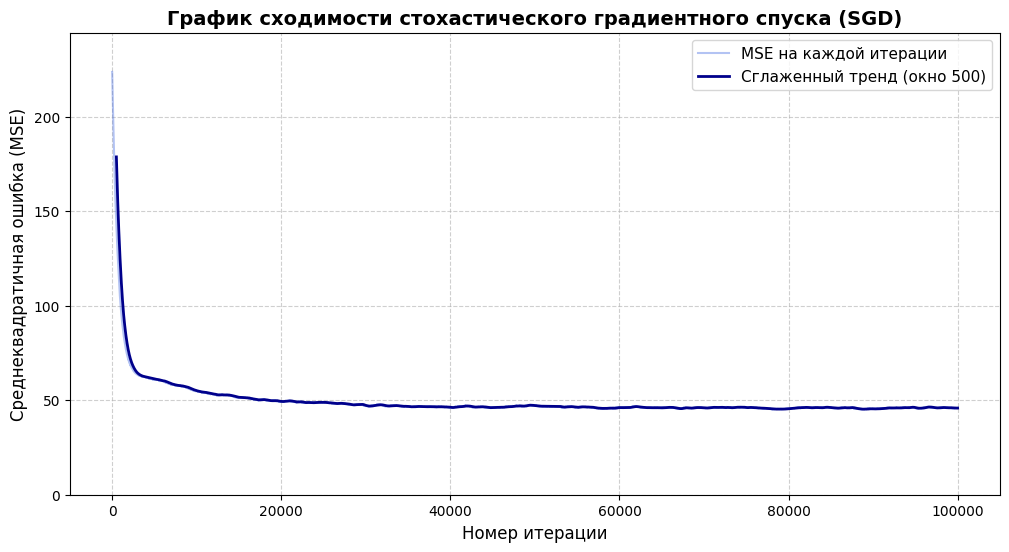

In [39]:
# ваш код
w_init = np.zeros(X.shape[1])
max_iterations = 100000

w_optimized, error_history = stochastic_gradient_descent(
    X=X, 
    y=y, 
    w_init=w_init, 
    eta=0.0001, 
    max_iter=max_iterations, 
    min_weight_dist=0
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(error_history, color='royalblue', alpha=0.4, label='MSE на каждой итерации')

# Добавляем сглаженный тренд (среднее), чтобы лучше видеть сходимость
# Считаем среднее, например, по каждые 500 итерациям
window_size = 500
if len(error_history) > window_size:
    smooth_errors = np.convolve(error_history, np.ones(window_size)/window_size, mode='valid')
    plt.plot(range(window_size - 1, len(error_history)), smooth_errors, 
             color='darkblue', linewidth=2, label=f'Сглаженный тренд (окно {window_size})')

plt.title('График сходимости стохастического градиентного спуска (SGD)', fontsize=14, fontweight='bold')
plt.xlabel('Номер итерации', fontsize=12)
plt.ylabel('Среднеквадратичная ошибка (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Ограничиваем ось Y, если в самом начале был сильный пик ошибки для читаемости
plt.ylim(0, max(error_history[100:]) * 1.2) 

plt.show()

**Выведите вектор весов, к которому сошелся метод.**

In [40]:
# ваш код
print("Оптимизированный вектор весов w:", w_optimized)

Оптимизированный вектор весов w: [12.15575714  3.79290429  3.64279739  0.45459534]


**Выведите среднеквадратичную ошибку на последней итерации.**

In [41]:
# ваш код
print("Финальное значение ошибки (MSE):", error_history[-1])

Финальное значение ошибки (MSE): 46.0046
